# Analysis of Causal Forest (mRS 0-2)

In [1]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
import shap

In [2]:
MRS_TARGET = 2

cate = pd.read_csv(f"./output/causal_forest_cate_estimates_{MRS_TARGET}.csv")

# Rename Unnamed: 0 as patient_id
cate.rename(columns={"Unnamed: 0": "patient_id"}, inplace=True)

# Group age by 10-year intervals
cate["age_group"] = pd.cut(cate["age"], bins=np.arange(0, 110, 10), right=False)

# Group stroke severity by 5-point intervals
cate["stroke_severity_group"] = pd.cut(cate["stroke_severity"], bins=np.arange(0, 50, 5), right=False)

In [3]:
cate.head()

,patient_id,prior_disability,stroke_severity,age,congestive_heart_failure,hypertension,diabetes,afib_anticoagulant,any_afib_diagnosis,ethnicity,mrs_0-2,treatment_group,cate,age_group,stroke_severity_group
0,2,1,13.0,47.5,0.0,0.0,0.0,0.0,1.0,White,0,early_thrombolysis_only,0.131215,"[40, 50)","[10, 15)"
1,7,1,6.0,82.5,0.0,0.0,1.0,1.0,1.0,White,1,neither,0.000000,"[80, 90)","[5, 10)"
2,12,3,7.0,92.5,0.0,1.0,0.0,0.0,0.0,White,0,early_thrombolysis_only,0.044762,"[90, 100)","[5, 10)"
3,16,4,7.0,82.5,0.0,0.0,0.0,1.0,1.0,White,0,neither,0.000000,"[80, 90)","[5, 10)"
4,17,0,9.0,62.5,0.0,0.0,0.0,0.0,0.0,White,1,late_thrombolysis_only,-0.151037,"[60, 70)","[5, 10)"


In [4]:
rename_dict = {
    "early_thrombolysis_only": "Early thrombolysis\nonly",
    "late_thrombolysis_only": "Late thrombolysis\nonly",
    "early_thrombectomy_only": "Early thrombectomy\nonly",
    "late_thrombectomy_only": "Late thrombectomy\nonly",
    "early_both": "Early both",
    "early_thrombolysis_late_thrombectomy": "Early thrombolysis,\nlate thrombectomy",
    "late_both": "Late both"
}

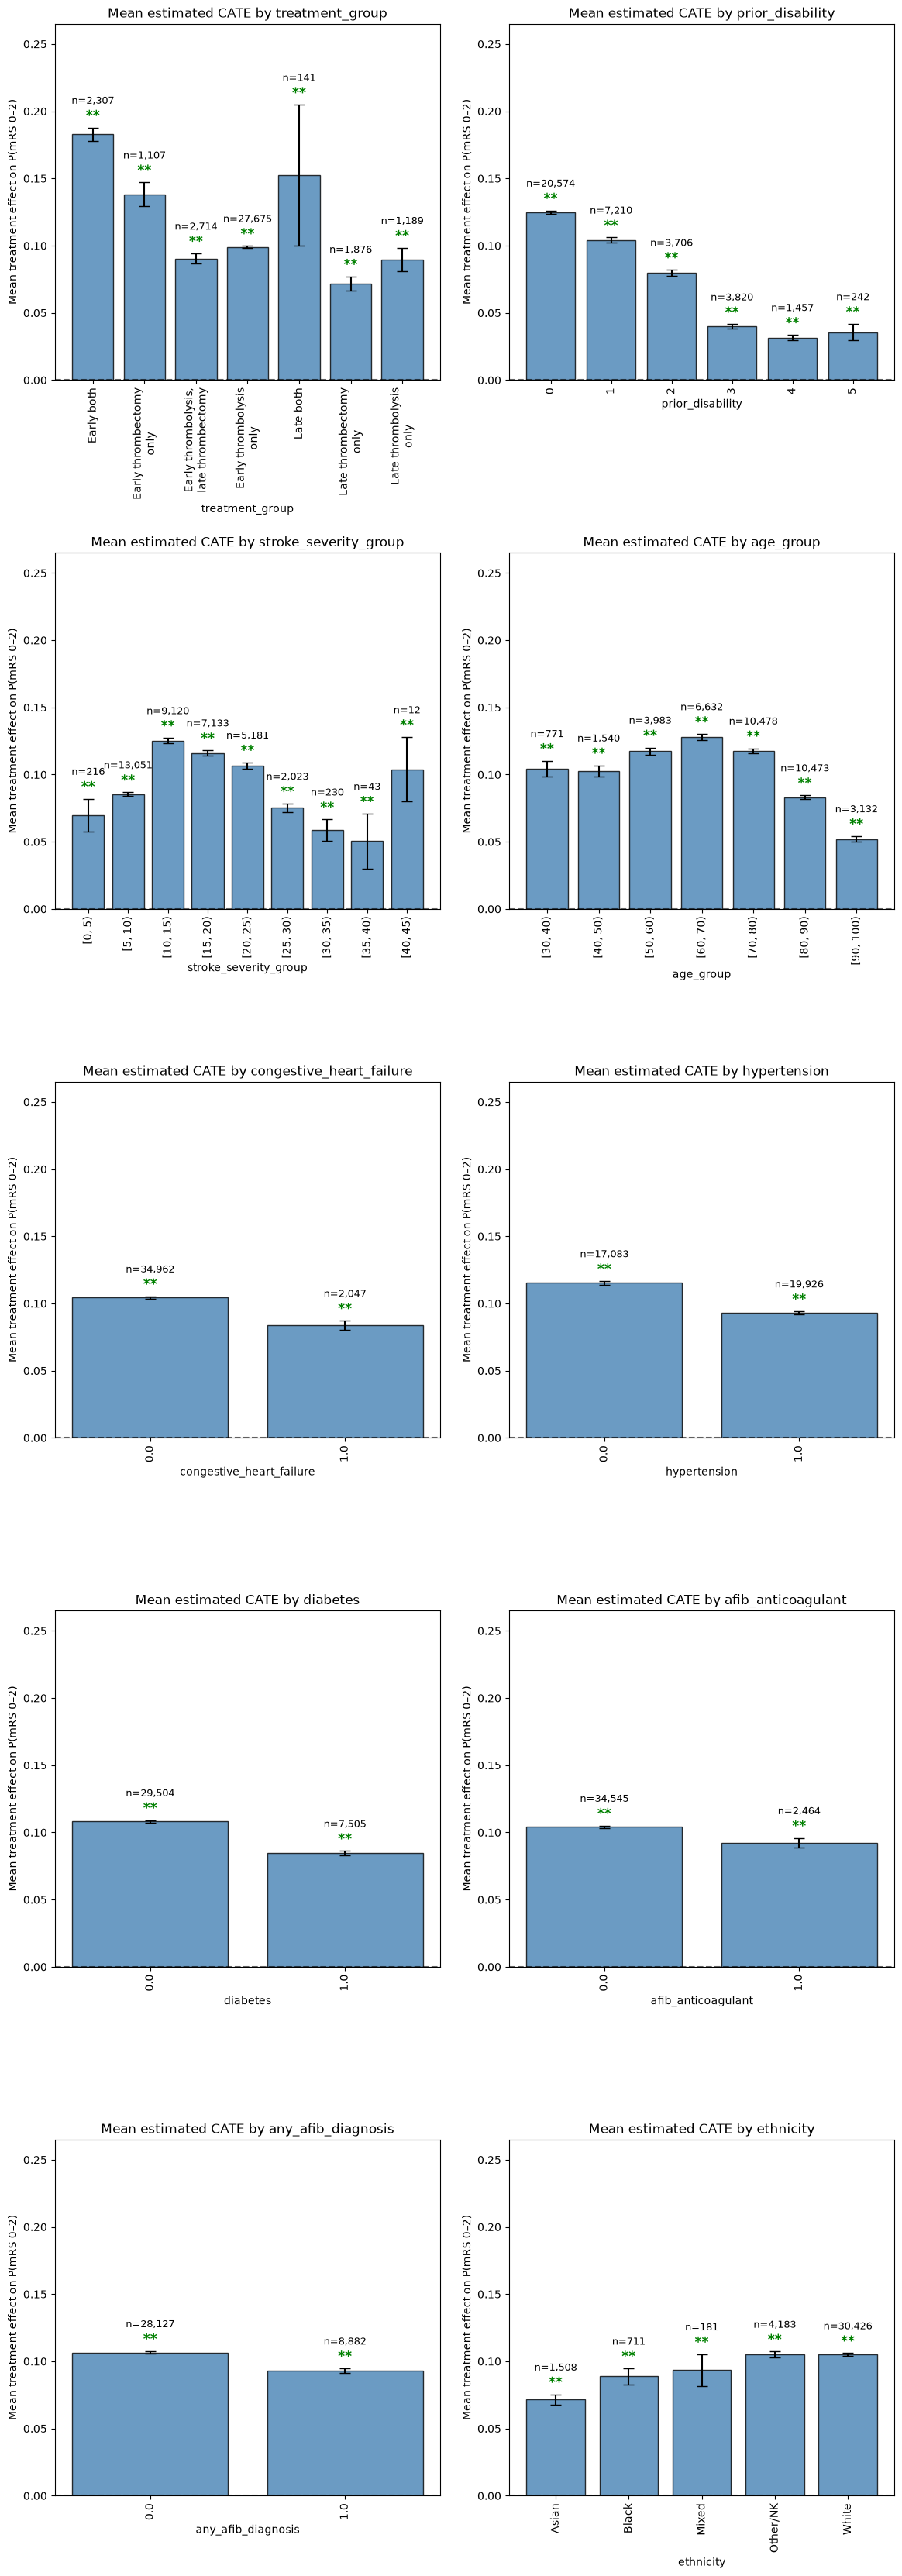

In [5]:
cate_treated = cate.loc[
    cate["treatment_group"] != "neither"
].copy()

features_to_plot = [
    "treatment_group",
    "prior_disability",
    "stroke_severity_group",
    "age_group",
    "congestive_heart_failure",
    "hypertension",
    "diabetes",
    "afib_anticoagulant",
    "any_afib_diagnosis",
    "ethnicity",
]

features_to_plot = [
    feature
    for feature in features_to_plot
    if feature in cate_treated.columns
]

ncols = 2
nrows = math.ceil(len(features_to_plot) / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(12, 7 * nrows),
    squeeze=False,
)
axes = axes.ravel()

for i, feature in enumerate(features_to_plot):
    ax = axes[i]
    feature_data = cate_treated[[feature, "cate"]].dropna()

    if feature_data.empty:
        ax.set_title(f"No data for {feature}")
        ax.axis("off")
        continue

    order = list(feature_data[feature].unique())

    if feature == "stroke_severity_group":

        def stroke_severity_key(value):
            if hasattr(value, "left"):
                return value.left

            if isinstance(value, tuple):
                return value[0]

            value_str = str(value).strip("()[]")
            try:
                return float(value_str.split(",")[0].strip())
            except (ValueError, AttributeError, IndexError):
                return float("inf")

        order = sorted(order, key=stroke_severity_key)
    else:
        order = sorted(order, key=lambda value: str(value))

    means = []
    lower_errors = []
    upper_errors = []
    confidence_limits = []

    for level in order:
        values = feature_data.loc[
            feature_data[feature] == level, "cate"
        ].to_numpy()

        mean = values.mean()
        se = (
            values.std(ddof=1) / np.sqrt(len(values))
            if len(values) > 1
            else 0.0
        )

        ci_lower_95 = mean - 1.96 * se
        ci_upper_95 = mean + 1.96 * se
        ci_lower_99 = mean - 2.576 * se
        ci_upper_99 = mean + 2.576 * se

        means.append(mean)
        lower_errors.append(mean - ci_lower_95)
        upper_errors.append(ci_upper_95 - mean)
        confidence_limits.append(
            (ci_lower_95, ci_upper_95, ci_lower_99, ci_upper_99)
        )

    x_positions = np.arange(len(order))

    ax.bar(
        x_positions,
        means,
        yerr=[lower_errors, upper_errors],
        capsize=5,
        color="steelblue",
        edgecolor="black",
        alpha=0.8,
    )

    for x_pos, limits in zip(x_positions, confidence_limits):
        ci_lower_95, ci_upper_95, ci_lower_99, ci_upper_99 = limits

        if ci_lower_99 > 0:
            stars, color = "**", "green"
        elif ci_upper_99 < 0:
            stars, color = "**", "red"
        elif ci_lower_95 > 0:
            stars, color = "*", "green"
        elif ci_upper_95 < 0:
            stars, color = "*", "red"
        else:
            continue

        count = int(feature_data[feature].eq(order[x_pos]).sum())
        annotation_y = ci_upper_95 if color == "green" else 0

        ax.annotate(
            stars,
            xy=(x_pos, annotation_y),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
            color=color,
            fontsize=12,
            fontweight="bold",
        )

        ax.annotate(
            f"n={count:,}",
            xy=(x_pos, annotation_y),
            xytext=(0, 20),
            textcoords="offset points",
            ha="center",
            va="bottom",
            color="black",
            fontsize=9,
        )

    if feature == "treatment_group":
        display_order = [
            rename_dict.get(str(value), str(value))
            for value in order
        ]
    else:
        display_order = [str(value) for value in order]

    ax.axhline(0, color="black", linestyle="--", alpha=0.6)
    ax.set_title(f"Mean estimated CATE by {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel(f"Mean treatment effect on P(mRS 0–{MRS_TARGET})")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(display_order, rotation=90)

for ax in axes[len(features_to_plot):]:
    ax.axis("off")

active_axes = axes[:len(features_to_plot)]

if len(active_axes) > 0:
    y_min = min(ax.get_ylim()[0] for ax in active_axes)
    y_max = max(ax.get_ylim()[1] for ax in active_axes)

    for ax in active_axes:
        ax.set_ylim(y_min, y_max + 0.05)

plt.tight_layout(rect=(0, 0, 1, 0.96), pad=2)
plt.savefig(
    f"./output/cate_analysis_mrs_{MRS_TARGET}.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()
